In [1]:
import sys
import os

# Add the root of the project to the path
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

# init

In [18]:
import pandas as pd

source_file='icdar_test_private_df_20250716_101521.csv' 
#"icdar_train_df_20250514_175905.csv" #icdar_test_private_df_20250716_101521.csv #icdar_test_public_df_20250716_101521.csv
train_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{source_file}")
gw=15
prop=1
n_cc=1
resolution=448
stride=int(resolution/2)
sort_by="black_ratio"
running = 'new-laptop'
saved = 'old-laptop'
#i select the m patches per file that have the highest number of cc
m = 50


In [19]:
train_df = pd.read_csv(f"{source_path}\\outputs\\preprocessed_data\\{source_file}")
train_df=file_IO.change_filename_from_to(train_df, fr=saved, to=running)

In [20]:
train_df.head()

,writer,isEng,same_text,file_name,male,Usage
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest
1,283,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest
2,283,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest
3,283,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest
4,285,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest


# run

In [21]:
#train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row, axis=1,args=(gw, n_cc,prop)), []))
#train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_resolution, axis=1,args=(resolution,stride, n_cc)), []))
train_df_expanded = pd.DataFrame(sum(train_df.apply(image_processing.process_row_body, axis=1,args=()), []))
train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,Usage,x,y,x2,y2
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,524,2466,1370
1,283,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1016,2472,2322
2,283,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,624,2466,1439
3,283,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1176,2472,2503
4,285,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,390,2472,1243
5,285,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,975,2472,2218
6,285,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,538,2472,1396
7,285,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,1186,2472,3267
8,289,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,458,2466,1257
9,289,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1034,2484,2787


In [22]:
train_df_expanded = train_df_expanded.reset_index(drop=True)
train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,Usage,x,y,x2,y2
0,283,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,524,2466,1370
1,283,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1016,2472,2322
2,283,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,624,2466,1439
3,283,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1176,2472,2503
4,285,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,390,2472,1243
5,285,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,975,2472,2218
6,285,1,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,538,2472,1396
7,285,1,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,0,PrivateTest,0,1186,2472,3267
8,289,0,0,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,458,2466,1257
9,289,0,1,C:\Users\andre\PhD\Datasets\ICDAR 2013 - Gende...,1,PrivateTest,0,1034,2484,2787


In [23]:
train_df_expanded_sorted = train_df_expanded.sort_values(by=sort_by, ascending=False)
train_df_expanded = train_df_expanded_sorted.groupby('file_name').head(m)   # Select top m patches per page

KeyError: 'black_ratio'

In [24]:
train_df_expanded = train_df_expanded.sort_values(by='index')
train_df_expanded = train_df_expanded.reset_index(drop=True)
train_df_expanded.head(10)

KeyError: 'index'

# Visual check

KeyError: 'index'

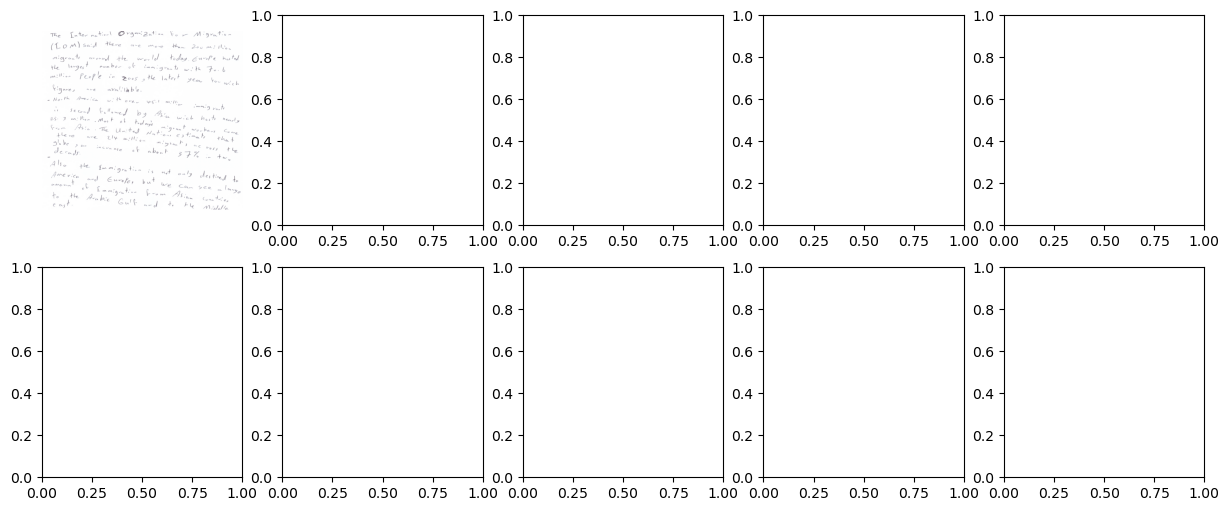

In [25]:
visualization.plot_cropped_sections(train_df_expanded)

In [27]:
train_df_expanded=file_IO.change_filename_from_to(train_df_expanded, fr=running, to=saved) #to be compatible with the other scripts

In [28]:
train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,Usage,x,y,x2,y2
0,283,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,524,2466,1370
1,283,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1016,2472,2322
2,283,1,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,624,2466,1439
3,283,1,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1176,2472,2503
4,285,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,390,2472,1243
5,285,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,975,2472,2218
6,285,1,0,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,538,2472,1396
7,285,1,1,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,1186,2472,3267
8,289,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,458,2466,1257
9,289,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1034,2484,2787


# tests

In [ ]:
index_counts = train_df_expanded['index'].value_counts()
all_counts_correct = (index_counts == m).all()
print(f"Each unique index appears {m} times: {all_counts_correct}")
if not all_counts_correct:
    print("Indices with incorrect counts:")
    print(index_counts[index_counts != m])

In [29]:
# The number of patches per writer, should be 5*4
len(train_df_expanded)/282

20.0

In [42]:
tests.check_randomization(train_df_expanded)
tests.check_grouping(train_df_expanded)
tests.check_occurrences(train_df_expanded,count=4*m)

Number of rows where train == 1: 15180
Fraction of rows where train == 1: 0.90
The train column is constant for all writers.
Each unique writer value occurs on exactly 60 rows.


In [35]:
import random
random_numbers = random.sample(range(1, len(train_df_expanded)), 10)
for n in random_numbers:
    print(n)
    print('first df \n', train_df_expanded.iloc[n])
    i=train_df_expanded['writer'][n]
    #print('writer', i)
    print(train_df[train_df['writer'] == i])
    print('-------------')

3763
first df 
 writer                                                       189
isEng                                                          0
same_text                                                      0
file_name      D:\download\PD project\datasets\ICDAR 2013 - G...
male                                                           0
train                                                          1
index                                                        752
x                                                            984
y                                                            492
x2                                                          1230
y2                                                           738
n_cc                                                          21
black_ratio                                             0.054977
Name: 3763, dtype: object
     writer  isEng  same_text  \
752     189      0          0   
753     189      0          1   
754     189   

# save

In [29]:
train_df_expanded['index']=train_df_expanded.index
train_df_expanded.head(10)

,writer,isEng,same_text,file_name,male,Usage,x,y,x2,y2,index
0,283,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,524,2466,1370,0
1,283,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1016,2472,2322,1
2,283,1,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,624,2466,1439,2
3,283,1,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1176,2472,2503,3
4,285,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,390,2472,1243,4
5,285,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,975,2472,2218,5
6,285,1,0,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,538,2472,1396,6
7,285,1,1,D:\download\PD project\datasets\ICDAR 2013 - G...,0,PrivateTest,0,1186,2472,3267,7
8,289,0,0,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,458,2466,1257,8
9,289,0,1,D:\download\PD project\datasets\ICDAR 2013 - G...,1,PrivateTest,0,1034,2484,2787,9


In [30]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = os.path.join(source_path, "outputs", "preprocessed_data")
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist

#output_file = os.path.join(output_dir, f"icdar_train_df_body_{timestamp}.csv")
output_file = os.path.join(output_dir, f"icdar_train_df_patches_{timestamp}.csv")
train_df_expanded.to_csv(output_file, index=False)

print(f"Dataframe saved to {output_file}")

Dataframe saved to c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\preprocessed_data\icdar_train_df_patches_20251209_161732.csv


In [31]:
# Example usage:
LOG_FILE = output_dir+"\\file_metadata_log.json"
print(f"Log file path: {LOG_FILE}")
print(f"Output file path: {output_file}")
file_IO.add_or_update_file(
    output_file, LOG_FILE,
    custom_metadata={
        #"seed": seed,
        "m patches": m,
        "source_file": source_file,
        "gw": gw,
        "n_cc":n_cc,
        "prop": prop,
        "sort_by": sort_by,
        "resolution": resolution,
        "stride": stride,
        "description": '''
        body crops for test set''' 
    }
)

Log file path: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\preprocessed_data\file_metadata_log.json
Output file path: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\preprocessed_data\icdar_train_df_patches_20251209_161732.csv
icdar_train_df_patches_20251209_161732.csv
Updated log for icdar_train_df_patches_20251209_161732.csv


In [32]:
file_IO.read_metadata(
    output_file,
    log_path=LOG_FILE
)

Metadata for icdar_train_df_patches_20251209_161732.csv:
full_path: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\preprocessed_data\icdar_train_df_patches_20251209_161732.csv
size_bytes: 77271
created: 2025-12-09T16:17:32.918014
modified: 2025-12-09T16:17:32.924010
accessed: 2025-12-09T16:17:32.924010
m patches: 50
source_file: icdar_test_private_df_20250716_101521.csv
gw: 15
n_cc: 1
prop: 1
sort_by: black_ratio
resolution: 448
stride: 224
description: 
        body crops for test set


In [30]:
'''import pyarrow as pa
import pyarrow.parquet as pq
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Your metadata
metadata = {
    'author': 'Andrea Morelli',
    'date': timestamp,
    'description': 'dividing images in 25th and counting the number of ccs, using a threshold of 10. I extract the 5 patches with more ccs for each unique file'
}

# Convert DataFrame to pyarrow Table
table = pa.Table.from_pandas(train_df_expanded)

# Convert metadata to bytes and attach to schema
# Parquet metadata must be a dict of bytes
meta_bytes = {k: str(v).encode('utf-8') for k, v in metadata.items()}
table = table.replace_schema_metadata(meta_bytes)

# Write to Parquet file
pq.write_table(table, 'icdar_train_df_cc_5patches_perName.parquet')'''

'import pyarrow as pa\nimport pyarrow.parquet as pq\nfrom datetime import datetime\ntimestamp = datetime.now().strftime("%Y%m%d_%H%M%S")\n\n# Your metadata\nmetadata = {\n    \'author\': \'Andrea Morelli\',\n    \'date\': timestamp,\n    \'description\': \'dividing images in 25th and counting the number of ccs, using a threshold of 10. I extract the 5 patches with more ccs for each unique file\'\n}\n\n# Convert DataFrame to pyarrow Table\ntable = pa.Table.from_pandas(train_df_expanded)\n\n# Convert metadata to bytes and attach to schema\n# Parquet metadata must be a dict of bytes\nmeta_bytes = {k: str(v).encode(\'utf-8\') for k, v in metadata.items()}\ntable = table.replace_schema_metadata(meta_bytes)\n\n# Write to Parquet file\npq.write_table(table, \'icdar_train_df_cc_5patches_perName.parquet\')'

# easy access

In [3]:
def reload_modules():
    import importlib
    import utils.image_processing as image_processing
    import utils.file_IO as file_IO
    import utils.visualization as visualization
    import utils.tests as tests

    importlib.reload(file_IO)
    importlib.reload(image_processing)
    importlib.reload(visualization)
    importlib.reload(tests)

    return image_processing, file_IO, visualization, tests
image_processing, file_IO, visualization, tests = reload_modules()